# Credit Card Credit Limit Prediction
### A Machine Learning Project
### Name - Aarush Soni

**Objective:** Predict a customer's `CREDIT_LIMIT` using their credit card usage behavior
(balance, purchases, cash advances, payments, tenure, etc.)

**Dataset:** `CC_GENERAL.csv` — 8,950 credit card holders, 18 behavioral features.

**Algorithms compared:**
1. Linear Regression (LR)
2. Decision Tree Regressor (DTR)
3. Random Forest Regressor (RF)
4. XGBoost Regressor (XGB)

**Workflow:** EDA → Data Cleaning → Feature Preparation → Model Training → Evaluation → Comparison

## 1. Import Libraries

In [1]:
try:
    import numpy as np
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy"])
    import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [3]:
df = pd.read_csv('CC GENERAL.csv')
print("Shape:", df.shape)
df.head()

Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Values

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


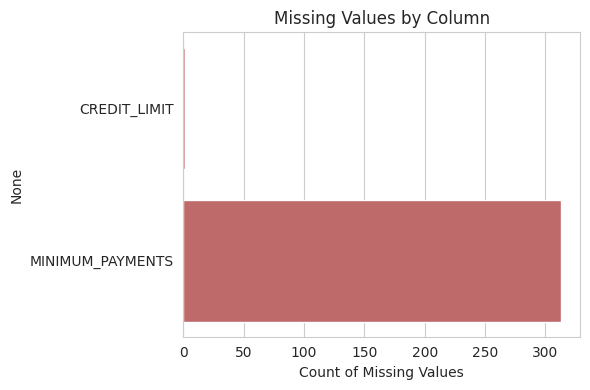

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

plt.figure(figsize=(6,4))
sns.barplot(x=missing.values, y=missing.index, color='indianred')
plt.title('Missing Values by Column')
plt.xlabel('Count of Missing Values')
plt.tight_layout()
plt.show()


### 3.2 Target Variable Distribution — CREDIT_LIMIT

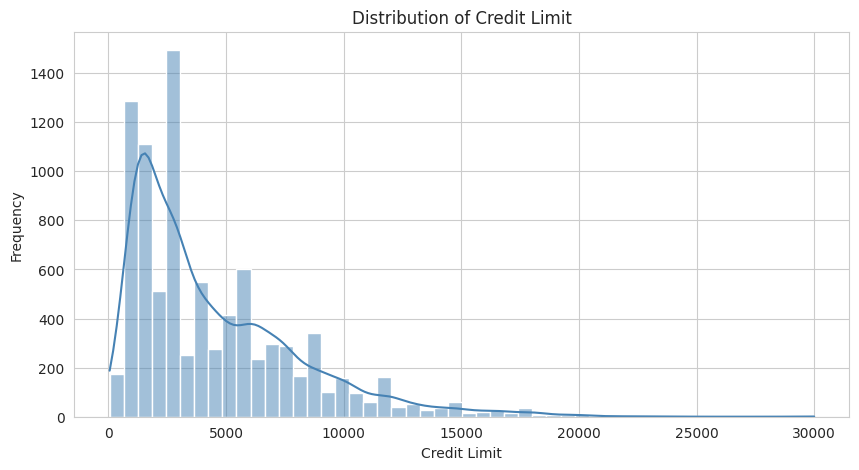

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df['CREDIT_LIMIT'].dropna(), bins=50, kde=True, color='steelblue')
plt.title('Distribution of Credit Limit')
plt.xlabel('Credit Limit')
plt.ylabel('Frequency')
plt.show()

### 3.3 Correlation Heatmap

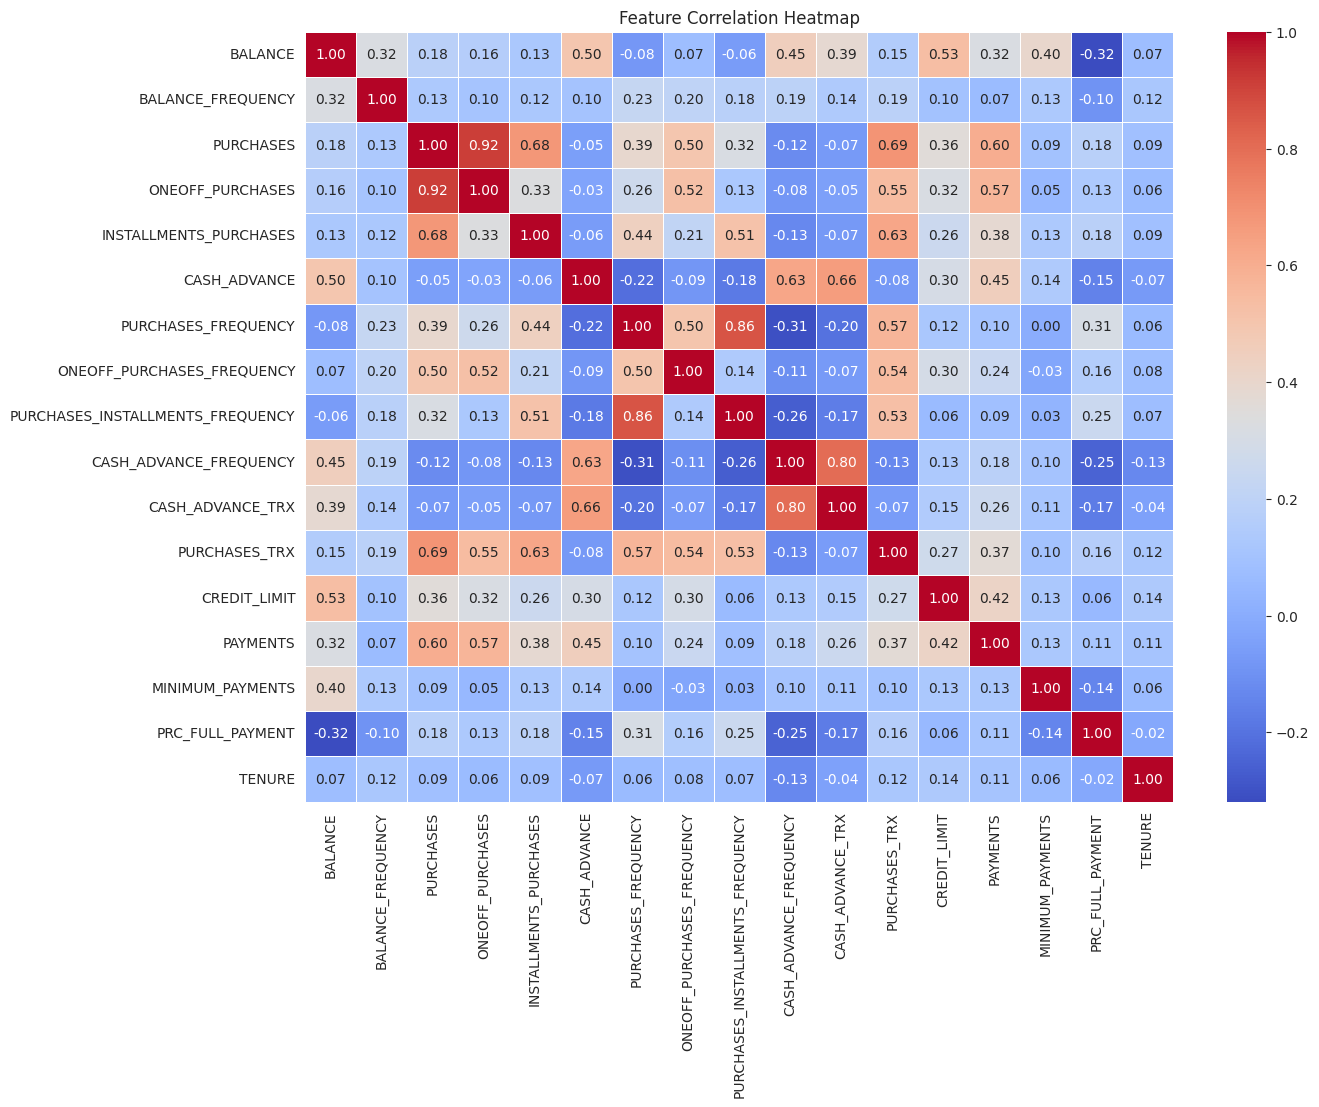

In [8]:
numeric_df = df.drop(columns=['CUST_ID'])
plt.figure(figsize=(14, 10))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


### 3.4 Correlation with Target (CREDIT_LIMIT)

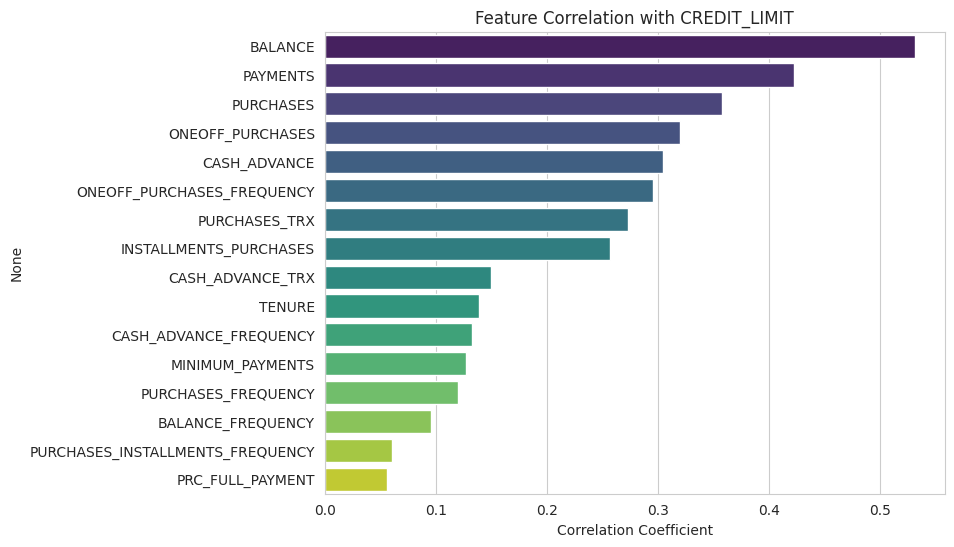

BALANCE                             0.531283
PAYMENTS                            0.421861
PURCHASES                           0.356963
ONEOFF_PURCHASES                    0.319724
CASH_ADVANCE                        0.303985
ONEOFF_PURCHASES_FREQUENCY          0.295038
PURCHASES_TRX                       0.272882
INSTALLMENTS_PURCHASES              0.256499
CASH_ADVANCE_TRX                    0.149700
TENURE                              0.139167
CASH_ADVANCE_FREQUENCY              0.132616
MINIMUM_PAYMENTS                    0.126671
PURCHASES_FREQUENCY                 0.119788
BALANCE_FREQUENCY                   0.095843
PURCHASES_INSTALLMENTS_FREQUENCY    0.060755
PRC_FULL_PAYMENT                    0.055672
Name: CREDIT_LIMIT, dtype: float64


In [9]:
target_corr = corr['CREDIT_LIMIT'].drop('CREDIT_LIMIT').sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='viridis')
plt.title('Feature Correlation with CREDIT_LIMIT')
plt.xlabel('Correlation Coefficient')
plt.show()
print(target_corr)

### 3.5 Distributions of Key Features

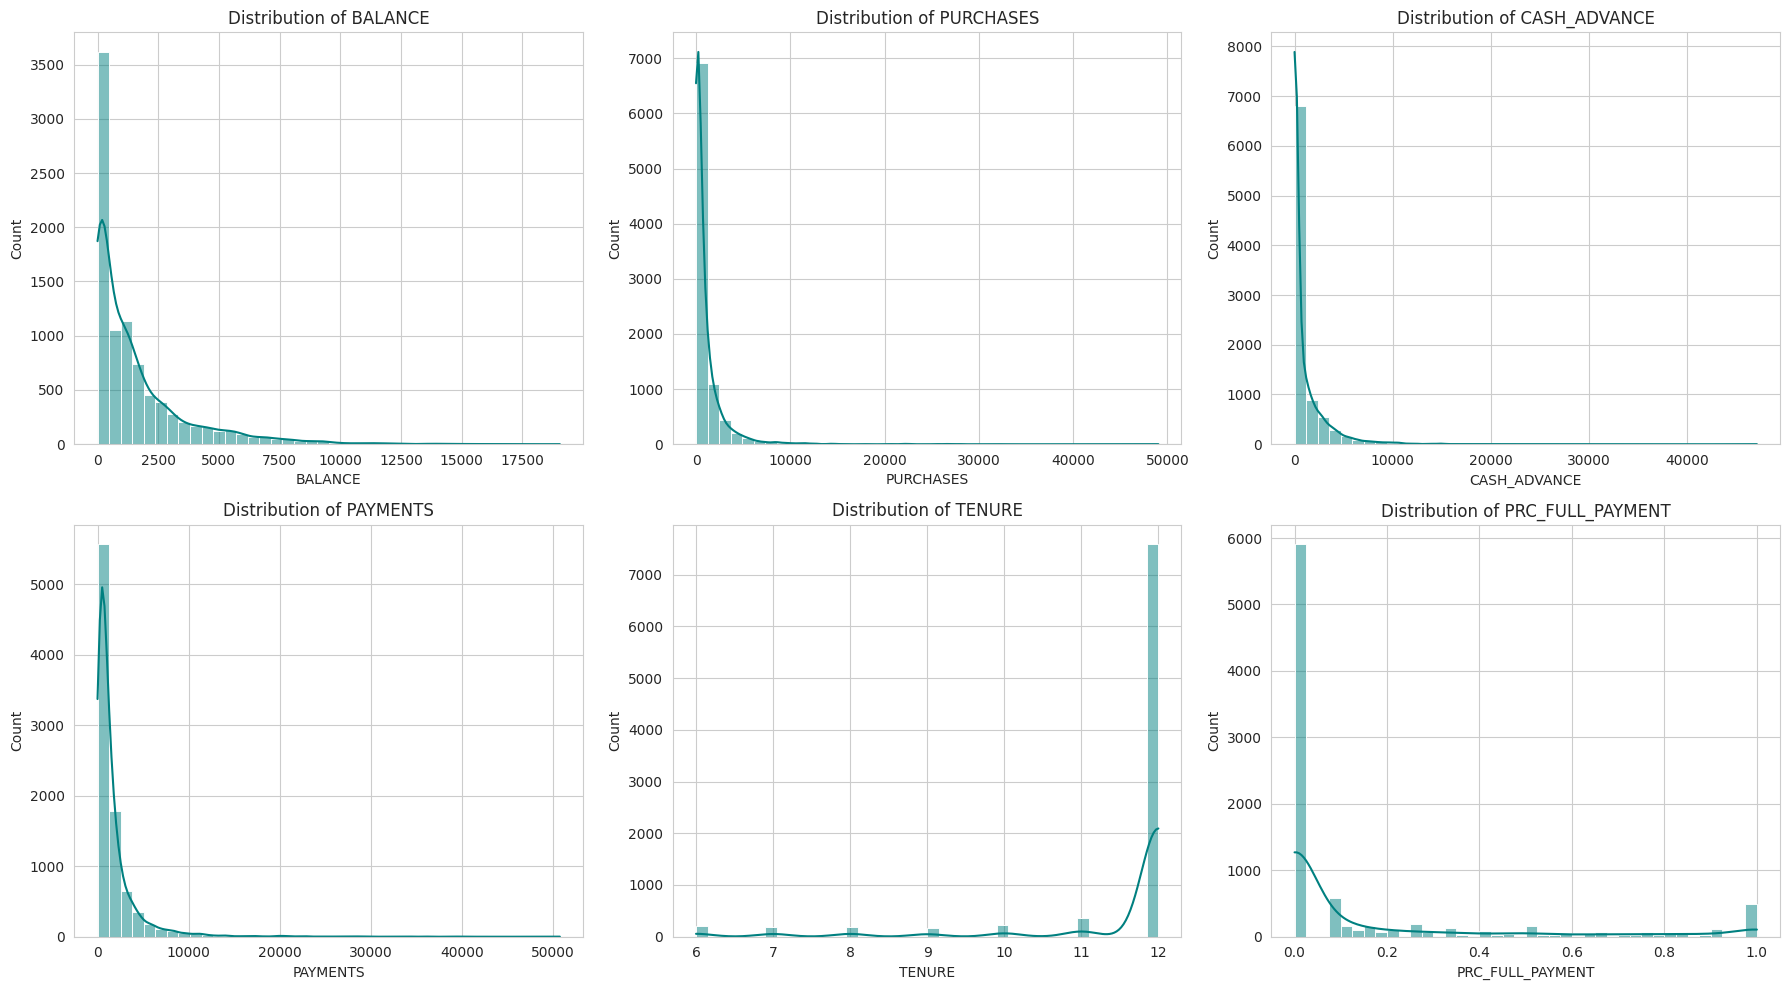

In [10]:
features_to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS', 'TENURE', 'PRC_FULL_PAYMENT']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(features_to_plot):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 3.6 Outlier Check with Boxplots

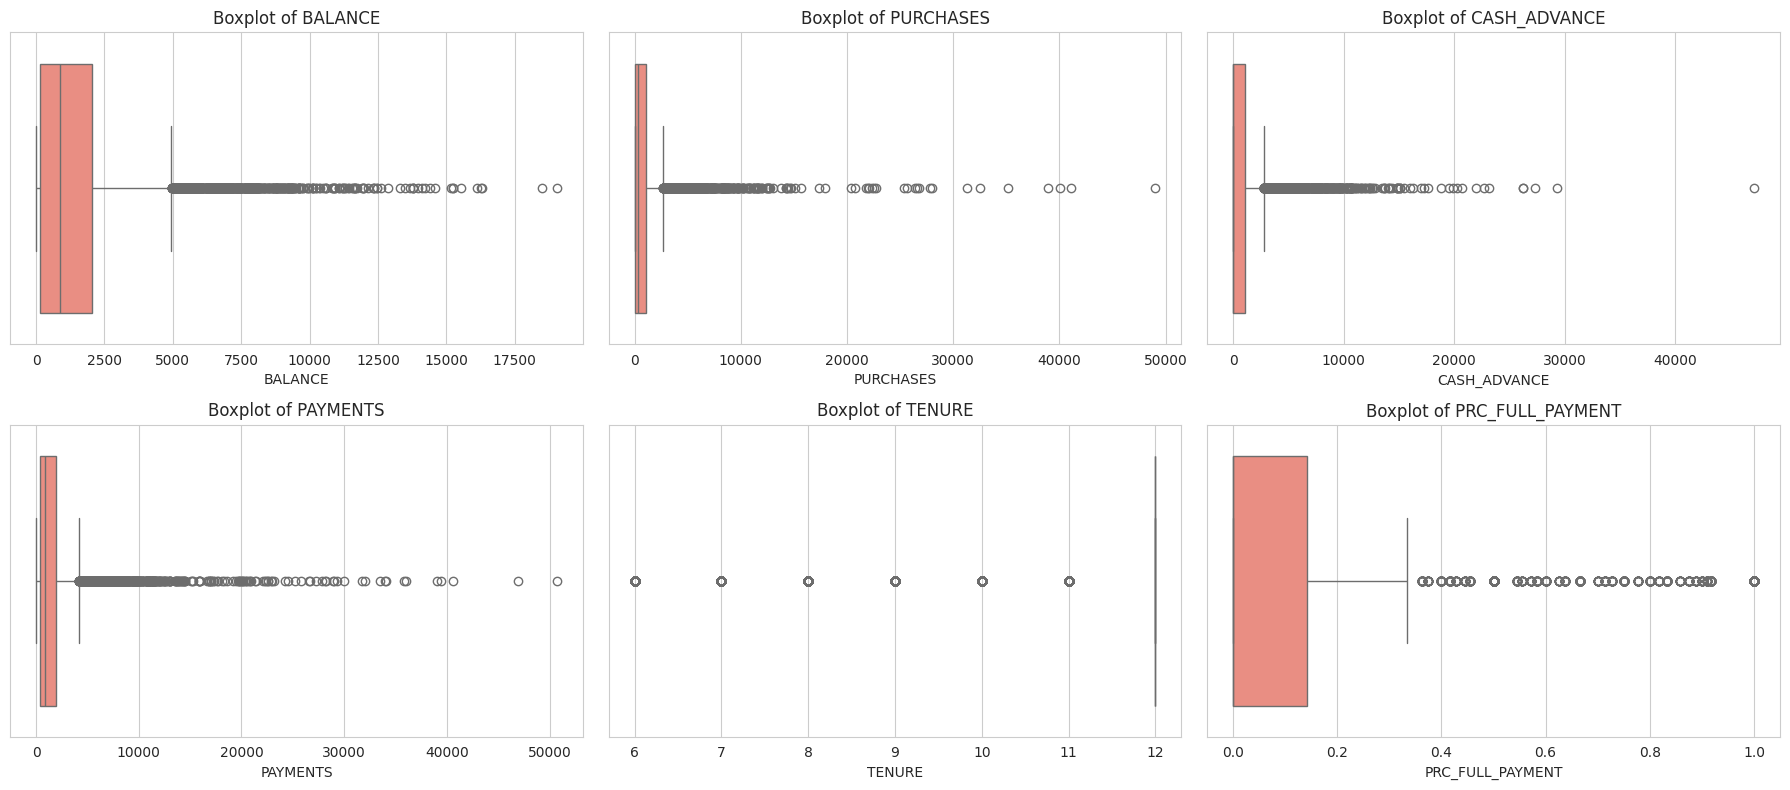

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(features_to_plot):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### 3.7 Relationship Between Purchases and Credit Limit

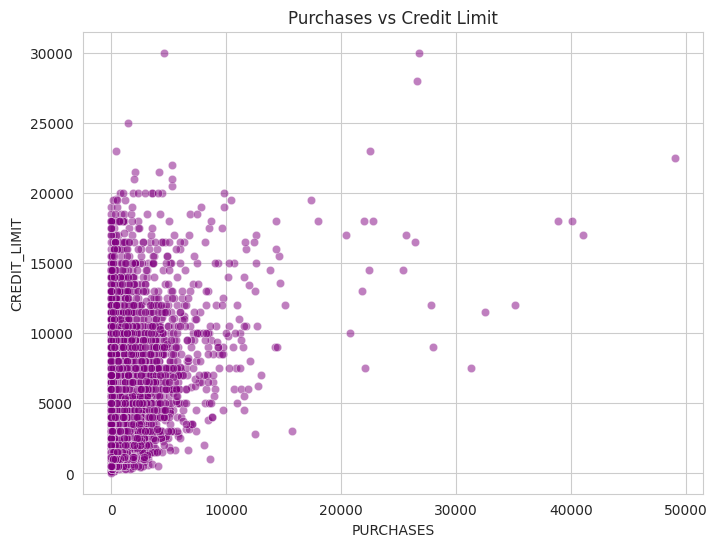

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PURCHASES', y='CREDIT_LIMIT', alpha=0.5, color='purple')
plt.title('Purchases vs Credit Limit')
plt.show()

## 4. Data Cleaning & Preprocessing

- Drop `CUST_ID` (identifier, not predictive)
- Impute missing `MINIMUM_PAYMENTS` and `CREDIT_LIMIT` with median
- Split features (X) and target (y)
- Train-test split (80/20)
- Scale features for Linear Regression

In [13]:
data = df.drop(columns=['CUST_ID']).copy()

# Impute missing values with median
data['MINIMUM_PAYMENTS'] = data['MINIMUM_PAYMENTS'].fillna(data['MINIMUM_PAYMENTS'].median())
data = data.dropna(subset=['CREDIT_LIMIT'])  # drop the 1 row missing target

print("Missing values after cleaning:")
print(data.isnull().sum().sum())

X = data.drop(columns=['CREDIT_LIMIT'])
y = data['CREDIT_LIMIT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Missing values after cleaning:
0
Train shape: (7159, 16)  Test shape: (1790, 16)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Model Training

We train four regression models and evaluate each with:
- **RMSE** (Root Mean Squared Error)
- **MAE** (Mean Absolute Error)
- **R² Score** (Coefficient of Determination)


### 5.1 Decision Tree Regressor (DTR)

In [15]:
dtr = DecisionTreeRegressor(max_depth=8, random_state=42)
dtr.fit(X_train, y_train)
dtr_pred = dtr.predict(X_test)

### 5.2 Random Forest Regressor (RF)

In [16]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

### 5.3 XGBoost Regressor (XGB)

In [17]:
xgb = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

### 5.4 Linear Regression (LR)

In [20]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)


## 6. Model Evaluation & Comparison

In [21]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2}

results = [
    evaluate('Linear Regression', y_test, lr_pred),
    evaluate('Decision Tree Regressor', y_test, dtr_pred),
    evaluate('Random Forest Regressor', y_test, rf_pred),
    evaluate('XGBoost Regressor', y_test, xgb_pred),
]

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df

,Model,RMSE,MAE,R2 Score
0,Random Forest Regressor,2541.726062,1797.451653,0.480657
1,XGBoost Regressor,2591.245966,1788.403908,0.460223
2,Linear Regression,2607.921580,1936.364157,0.453254
3,Decision Tree Regressor,2709.902008,1937.931299,0.409658


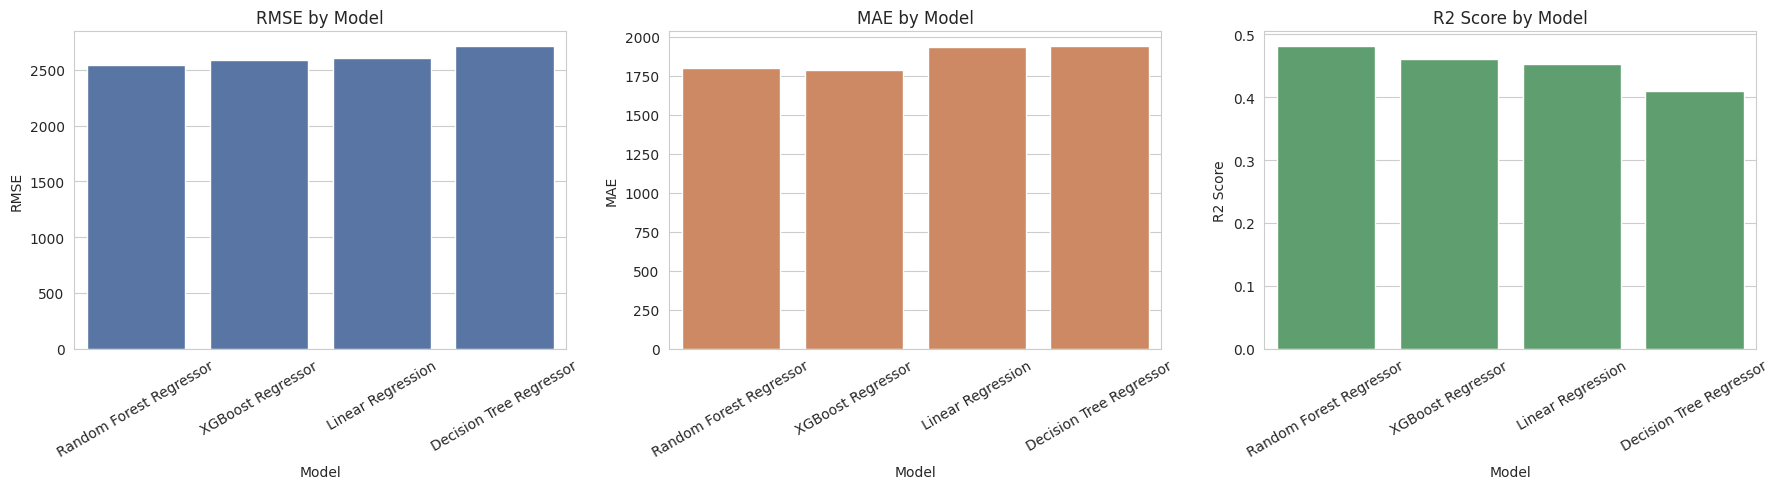

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
metrics = ['RMSE', 'MAE', 'R2 Score']
colors = ['#4C72B0', '#DD8452', '#55A868']
for i, m in enumerate(metrics):
    sns.barplot(data=results_df, x='Model', y=m, ax=axes[i], color=colors[i])
    axes[i].set_title(f'{m} by Model')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### 6.1 Actual vs Predicted (Best Model)

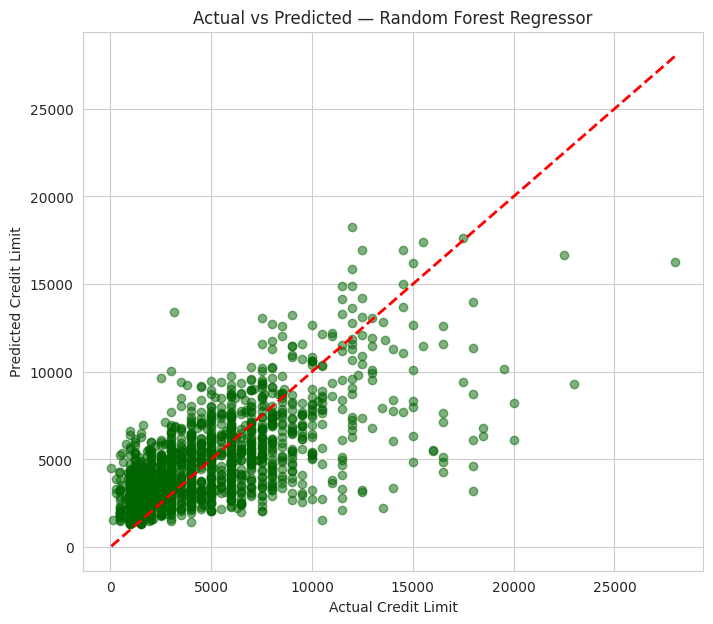

Best performing model: Random Forest Regressor


In [23]:
best_model_name = results_df.iloc[0]['Model']
pred_map = {
    'Linear Regression': lr_pred,
    'Decision Tree Regressor': dtr_pred,
    'Random Forest Regressor': rf_pred,
    'XGBoost Regressor': xgb_pred
}
best_pred = pred_map[best_model_name]

plt.figure(figsize=(8,7))
plt.scatter(y_test, best_pred, alpha=0.5, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Credit Limit')
plt.ylabel('Predicted Credit Limit')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.show()

print(f"Best performing model: {best_model_name}")


### 6.2 Feature Importance (Random Forest & XGBoost)

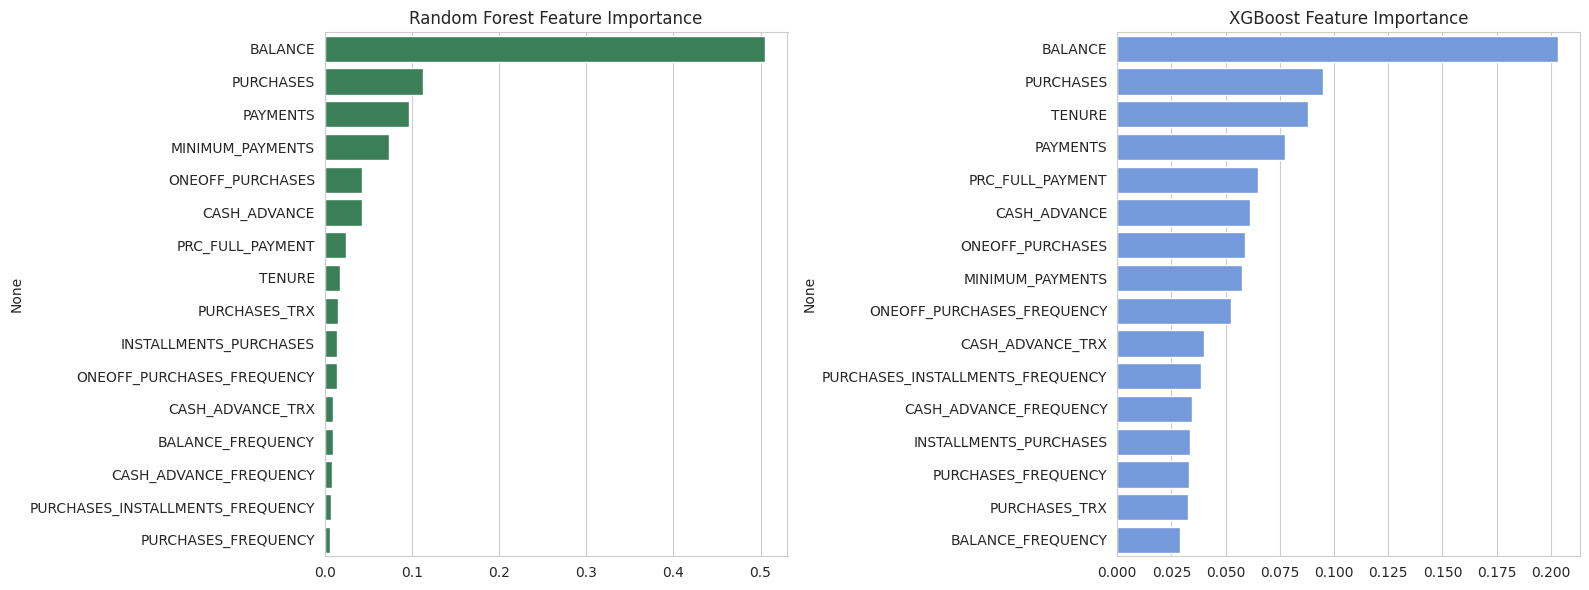

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=rf_importance.values, y=rf_importance.index, ax=axes[0], color='seagreen')
axes[0].set_title('Random Forest Feature Importance')

xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=xgb_importance.values, y=xgb_importance.index, ax=axes[1], color='cornflowerblue')
axes[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.show()


## 7. Conclusion

- All four models were trained to predict `CREDIT_LIMIT` from customer credit card usage behavior.
- Tree-based ensemble methods (Random Forest, XGBoost) generally outperform Linear Regression on this
  dataset because the relationship between spending behavior and credit limit is non-linear.
- `PAYMENTS`, `PURCHASES`, and `BALANCE` tend to be the most influential features in predicting credit limit.
- The comparison table and charts above make it easy to justify which model is best suited for deployment,
  based on the trade-off between interpretability (Linear Regression) and accuracy (XGBoost/Random Forest).

**Possible extensions:**
- Hyperparameter tuning with GridSearchCV / RandomizedSearchCV
- Cross-validation for more robust performance estimates
- Log-transforming skewed features (e.g., BALANCE, CASH_ADVANCE) before Linear Regression
- Trying clustering (K-Means) on this dataset for customer segmentation as a separate unsupervised task